## Ungraded Lab: MNIST Autoencoder

You will now work on an autoencoder that works on the [MNIST dataset](https://www.tensorflow.org/datasets/catalog/mnist). This will encode the inputs to lower resolution images. The decoder should then be able to generate the original input from this compressed representation.

In [1]:
!pip install tensorflow_datasets

## Imports

In [4]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 787.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 127.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 107.8 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [3]:
import tensorflow as tf
import tensorflow_datasets as tfds

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense
from tensorflow.keras import Input, Model

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


## Prepare the Dataset

You will load the MNIST data from TFDS into train and test sets. Let's first define a preprocessing function for normalizing and flattening the images. Since we'll be training an autoencoder, this will return `image, image` because the input will also be the target or label while training.


In [5]:
def map_image(image, label):
  '''Normalizes and flattens the image. Returns image as input and label.'''
  image = tf.cast(image, dtype=tf.float32)
  image = image / 255.0
  image = tf.reshape(image, shape=(784,))

  return image, image

In [6]:
# Load the train and test sets from TFDS

BATCH_SIZE = 128
SHUFFLE_BUFFER_SIZE = 1024

train_dataset = tfds.load('mnist', as_supervised=True, split='train')
train_dataset = train_dataset.map(map_image)
train_dataset = train_dataset.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE).repeat()

test_dataset = tfds.load('mnist', as_supervised=True, split='test')
test_dataset = test_dataset.map(map_image)
test_dataset = test_dataset.batch(BATCH_SIZE).repeat()

## Build the Model

You will now build a simple autoencoder to ingest the data. Like before, the encoder will compress the input and reconstructs it in the decoder output.

[![Deep.png](https://i.postimg.cc/02RbJk51/Deep.png)](https://postimg.cc/G9KcW1sX)

In [8]:
def deep_autoencoder(inputs):
  encoder=Dense(units=128,activation='relu')(inputs)
  encoder=Dense(units=64,activation='relu')(encoder)
  encoder=Dense(units=32,activation='relu')(encoder)
  decoder=Dense(units=64,activation='relu')(encoder)
  decoder=Dense(units=128,activation='relu')(decoder)
  decoder=Dense(units=784,activation='sigmoid')(decoder)
  return encoder, decoder

encoderinput = Input(shape=(784,))
encoder, decoder = deep_autoencoder(encoderinput)
autoencoder_model = Model(inputs=encoderinput, outputs=decoder)
encoder_model = Model(inputs=encoderinput, outputs=encoder)

## Compile the Model

You will setup the model for training. You can use binary crossentropy to measure the loss between pixel values that range from 0 (black) to 1 (white).

In [13]:
autoencoder_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='binary_crossentropy',metrics=['accuracy'])

## Train the Model

In [14]:
train_steps = 60000 // BATCH_SIZE
simple_auto_history = autoencoder_model.fit(train_dataset, steps_per_epoch=train_steps, epochs=50)

Epoch 1/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.0108 - loss: 0.2064
Epoch 2/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0120 - loss: 0.1315
Epoch 3/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0110 - loss: 0.1174
Epoch 4/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0117 - loss: 0.1104
Epoch 5/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0117 - loss: 0.1058
Epoch 6/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0123 - loss: 0.1020
Epoch 7/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0123 - loss: 0.0995
Epoch 8/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0128 - loss: 0.0978
Epoch 9/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0122 - loss: 0.0962
Epoch 10/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0124 - loss: 0.0950
Epoch 11/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0122 - loss: 0.0939
Epoch 12/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step

## Display sample results

You can now visualize the results. The utility functions below will help in plotting the encoded and decoded values.

In [15]:
def display_one_row(disp_images, offset, shape=(28, 28)):
  '''Display sample outputs in one row.'''
  for idx, test_image in enumerate(disp_images):
    plt.subplot(3, 10, offset + idx + 1)
    plt.xticks([])
    plt.yticks([])
    test_image = np.reshape(test_image, shape)
    plt.imshow(test_image, cmap='gray')


def display_results(disp_input_images, disp_encoded, disp_predicted, enc_shape=(8,4)):
  '''Displays the input, encoded, and decoded output values.'''
  plt.figure(figsize=(15, 5))
  display_one_row(disp_input_images, 0, shape=(28,28,))
  display_one_row(disp_encoded, 10, shape=enc_shape)
  display_one_row(disp_predicted, 20, shape=(28,28,))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


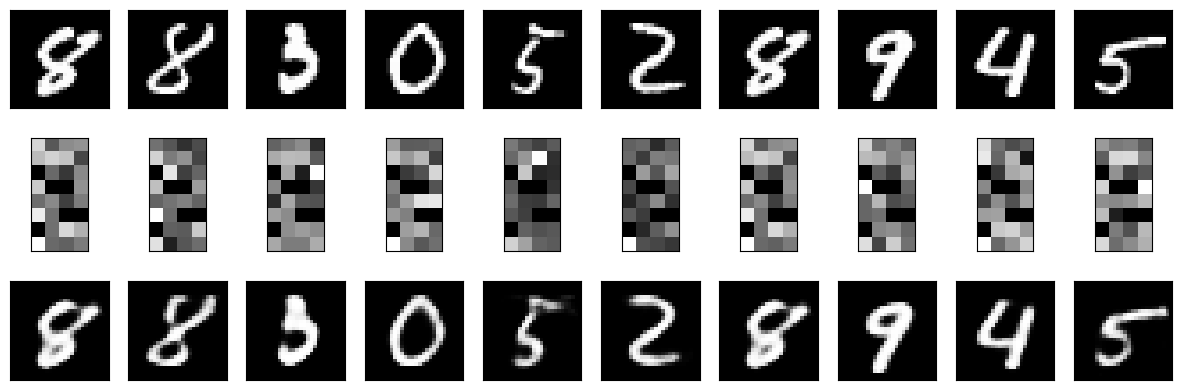

In [16]:
# Get one batch from the test_dataset for display and prediction
# We need to create an iterator for the dataset to get a single batch
test_batch_iterator = iter(test_dataset)
input_images_batch, _ = next(test_batch_iterator) # Get one batch (images, labels)

# Convert the batch to numpy for indexing and display
output_samples = input_images_batch.numpy()

# pick 10 random numbers to be used as indices to the list above
idxs = np.random.choice(BATCH_SIZE, size=10)

# get the encoder output using the tensor batch
encoded_predicted = encoder_model.predict(input_images_batch)

# get a prediction for the test batch
simple_predicted = autoencoder_model.predict(input_images_batch)

# display the 10 samples, encodings and decoded values!
display_results(output_samples[idxs], encoded_predicted[idxs], simple_predicted[idxs])

In [1]:
!pip uninstall -y tensorflow_datasets tensorflow-metadata protobuf
!pip install tensorflow_datasets

Found existing installation: tensorflow-datasets 4.9.9
Uninstalling tensorflow-datasets-4.9.9:
  Successfully uninstalled tensorflow-datasets-4.9.9
Found existing installation: tensorflow-metadata 1.12.0
Uninstalling tensorflow-metadata-1.12.0:
  Successfully uninstalled tensorflow-metadata-1.12.0
Found existing installation: protobuf 3.20.3
Uninstalling protobuf-3.20.3:
  Successfully uninstalled protobuf-3.20.3
  Using cached tensorflow_datasets-4.9.9-py3-none-any.whl.metadata (11 kB)
  Using cached protobuf-7.34.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
Using cached tensorflow_datasets-4.9.9-py3-none-any.whl (5.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 9.6 MB/s eta 0:00:00


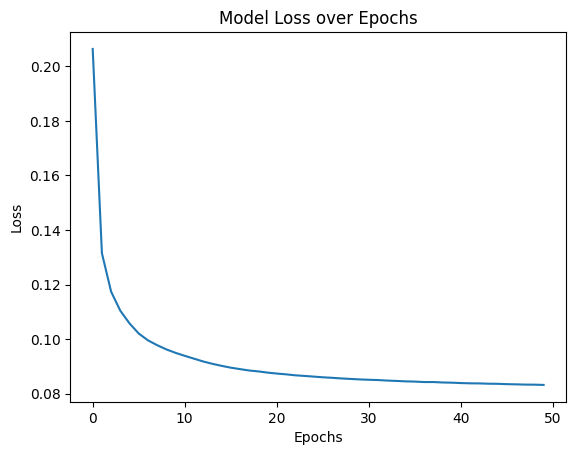

In [17]:
import matplotlib.pyplot as plt

# Plotting the training loss over epochs
plt.plot(simple_auto_history.history['loss'])
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()